In [354]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [355]:
df=pd.read_csv("car_crashes.csv")

In [356]:
df

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [357]:
df.columns

Index(['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous',
       'ins_premium', 'ins_losses', 'abbrev'],
      dtype='object')

In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


In [359]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total,51.0,15.790196,4.122002,5.900,12.7500,15.600,18.500,23.900
speeding,51.0,4.998196,2.017747,1.792,3.7665,4.608,6.439,9.450
alcohol,51.0,4.886784,1.729133,1.593,3.8940,4.554,5.604,10.038
not_distracted,51.0,13.573176,4.508977,1.760,10.4780,13.857,16.140,23.661
no_previous,51.0,14.004882,3.764672,5.900,11.3480,13.775,16.755,21.280
ins_premium,51.0,886.957647,178.296285,641.960,768.4300,858.970,1007.945,1301.520
ins_losses,51.0,134.493137,24.835922,82.750,114.6450,136.050,151.870,194.780


In [360]:
df.isnull().sum()

total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64

In [361]:
df.duplicated().sum()

0

# Univariate Analysis

C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\1102674835.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["total"])


<Axes: xlabel='total', ylabel='Density'>

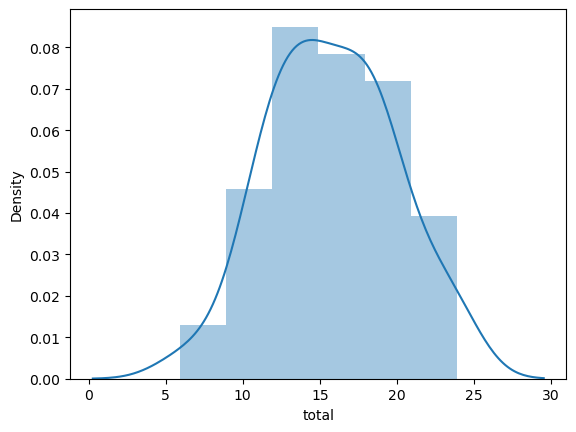

In [362]:
sns.distplot(df["total"])

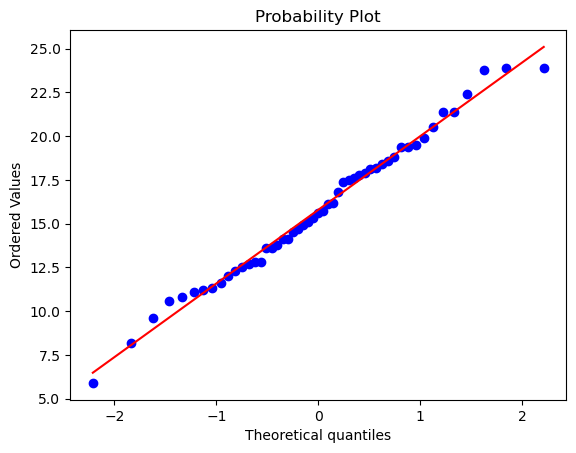

In [363]:
data=df["total"]
stats.probplot(data,dist="norm",plot=plt)
plt.show()

In [364]:
stats.kurtosis(df["total"])

-0.4257802374475923

In [365]:
stats.skew(df["total"])

0.04040684465119844

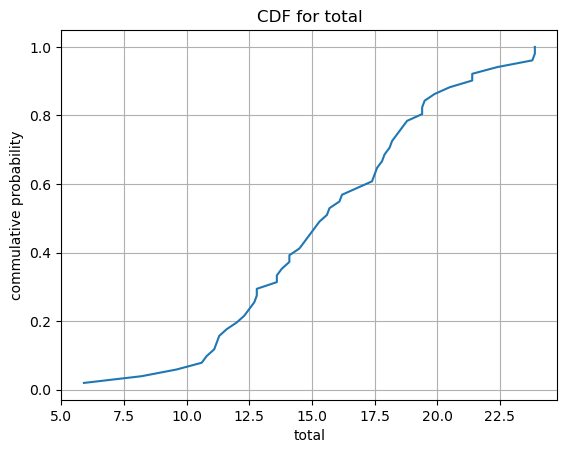

In [366]:
sorted_data=np.sort(df["total"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for total")
plt.xlabel("total")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

In [367]:
# less then 50% of total is 15.0

<Axes: ylabel='total'>

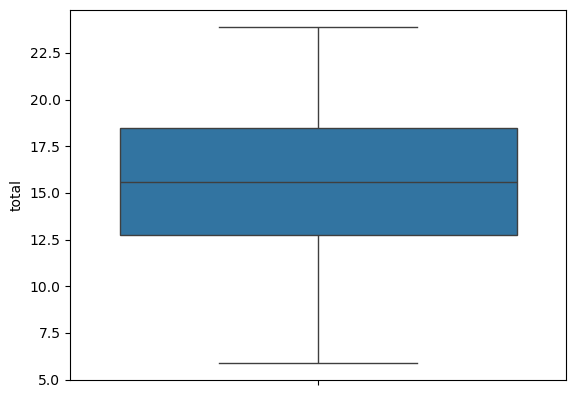

In [368]:
sns.boxplot(df["total"])

# 50% of total lies on 12.5 to 18

In [369]:
from scipy.stats import anderson

In [370]:
var=anderson(df["total"],dist="norm")

In [371]:
var

AndersonResult(statistic=0.19084468938967092, critical_values=array([0.539, 0.614, 0.736, 0.859, 1.022]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=15.79019607843137, scale=4.122002178648661)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [372]:
0.19084468938967092>0.736

False

# here we are reject null hypothesis so the data is not follows the normal distribution at 5% of significance level

In [373]:
from scipy.stats import kstest
z_score = (df["total"] - df["total"].mean()) / df["total"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
print(pvalue)
alpha=0.05
if pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

0.9774635380743572
Fail to reject H0


C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\2127910581.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["speeding"])


<Axes: xlabel='speeding', ylabel='Density'>

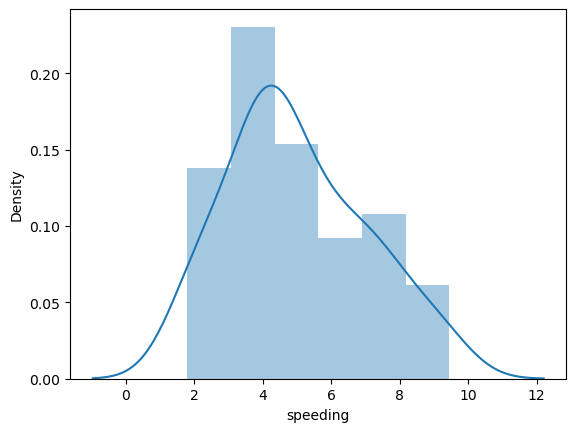

In [374]:
sns.distplot(df["speeding"])

<Axes: xlabel='speeding', ylabel='Count'>

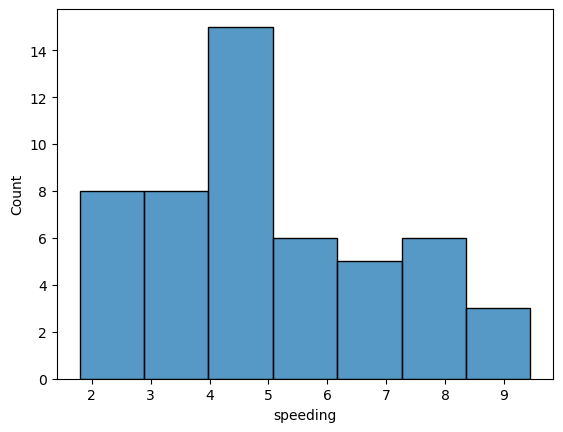

In [375]:
sns.histplot(df["speeding"])

# here we sees that speeding has a very strong relation with car crash

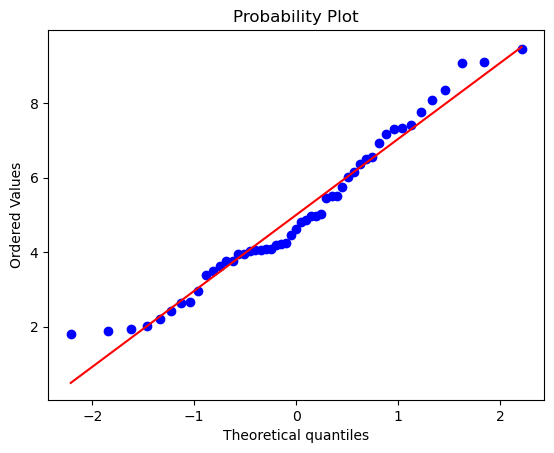

In [376]:
stats.probplot(df["speeding"],dist="norm",plot=plt)
plt.show()

In [377]:
stats.kurtosis(df["speeding"])

-0.5954196233460163

In [378]:
stats.skew(df["speeding"])

0.4172065468974466

# here we sees that the graph is right skewed

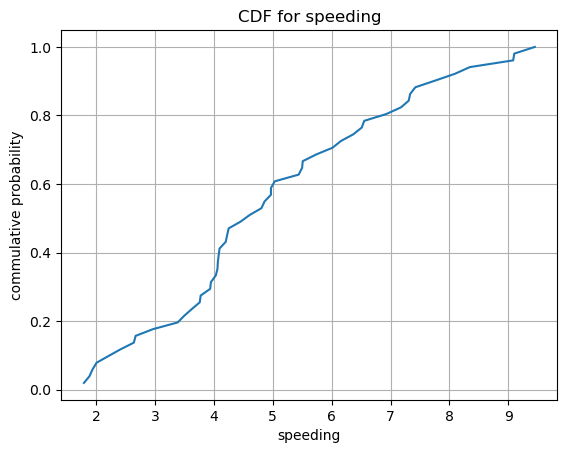

In [379]:
sorted_data=np.sort(df["speeding"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for speeding")
plt.xlabel("speeding")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

here we says that the the 60% car crashed by speeding 5

<Axes: ylabel='speeding'>

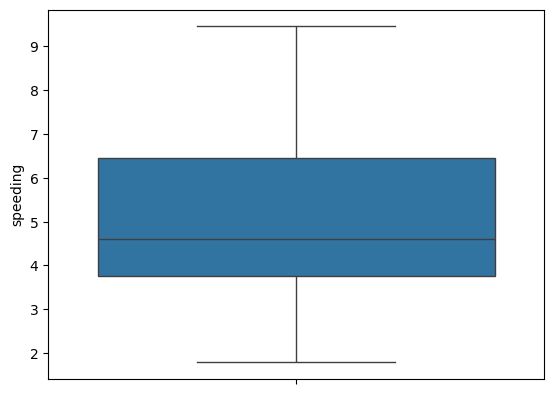

In [380]:
sns.boxplot(df["speeding"])

# 50% of data lies between the 38 to 65

In [381]:
from scipy.stats import kstest
z_score = (df["speeding"] - df["speeding"].mean()) / df["speeding"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
alpha = 0.05
if pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Fail to reject H0


In [382]:
# A-D test 
var=anderson(df["speeding"],dist="norm")

In [383]:
var

AndersonResult(statistic=0.580563267077828, critical_values=array([0.539, 0.614, 0.736, 0.859, 1.022]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=4.998196078431373, scale=2.0177470903917354)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [384]:
0.580563267077828<0.736

True

In [385]:
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\3201832786.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["alcohol"])


<Axes: xlabel='alcohol', ylabel='Density'>

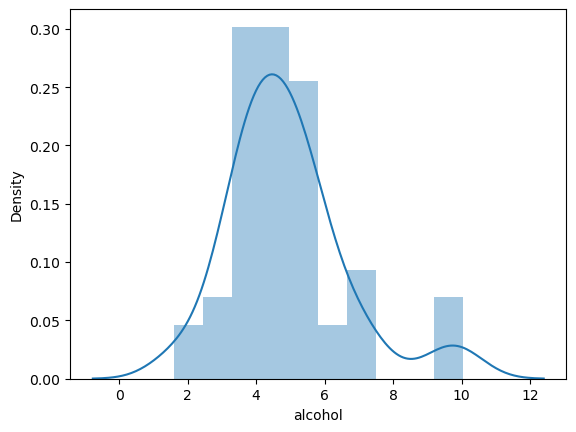

In [386]:
sns.distplot(df["alcohol"])

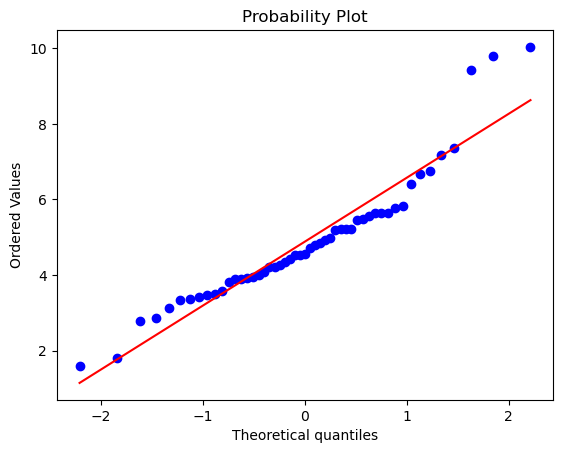

In [387]:
stats.probplot(df["alcohol"],dist="norm",plot=plt)
plt.show()

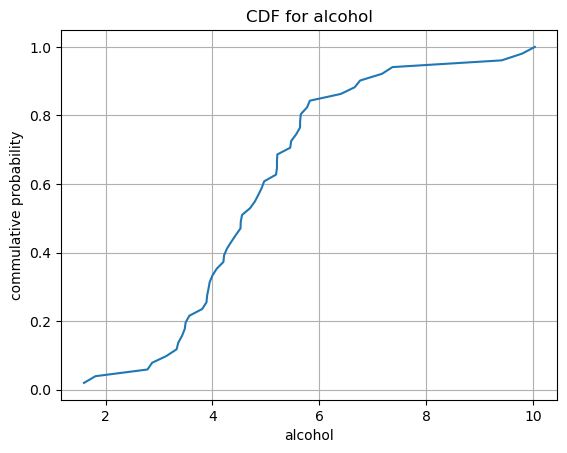

In [388]:
sorted_data=np.sort(df["alcohol"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for alcohol")
plt.xlabel("alcohol")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

# in CDF be observing that alcohol is not related to the car crashes

In [389]:
stats.kurtosis(df["alcohol"])

1.768371533257886

# The distribution has heavier tails 

In [390]:
stats.skew(df["alcohol"])

1.0996880125685116

# here we sees that the distribution is right skewed

<Axes: ylabel='alcohol'>

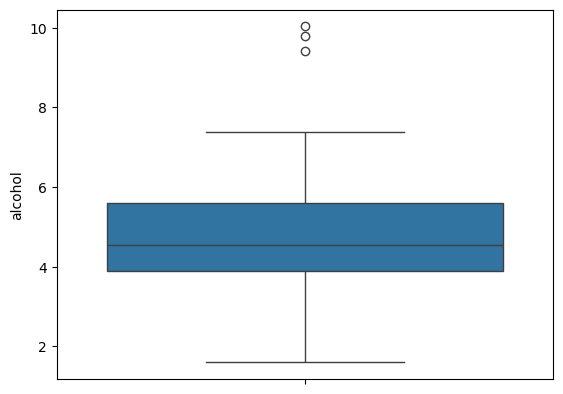

In [391]:
sns.boxplot(df["alcohol"])

# some of the outlier detected

In [392]:
from scipy.stats import kstest
z_score = (df["alcohol"] - df["alcohol"].mean()) / df["alcohol"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
alpha = 0.05
if pvalue < alpha:
    print("Reject H0 ")
else:
    print("Fail to reject H0 ")

Fail to reject H0 


# After doing tye K-S test we fail to reject H0 hypothesis data maybe realte with the car_crash

C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\743952441.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["not_distracted"])


<Axes: xlabel='not_distracted', ylabel='Density'>

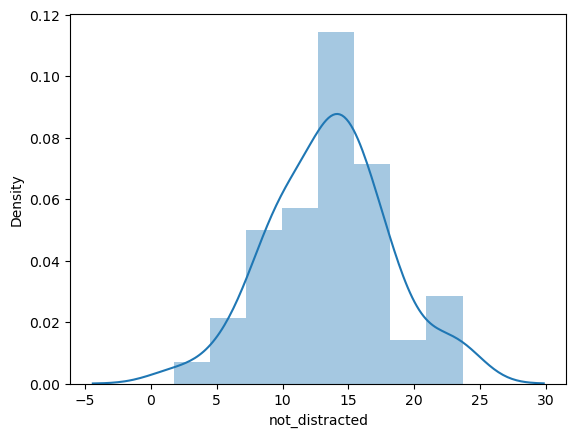

In [393]:
sns.distplot(df["not_distracted"])

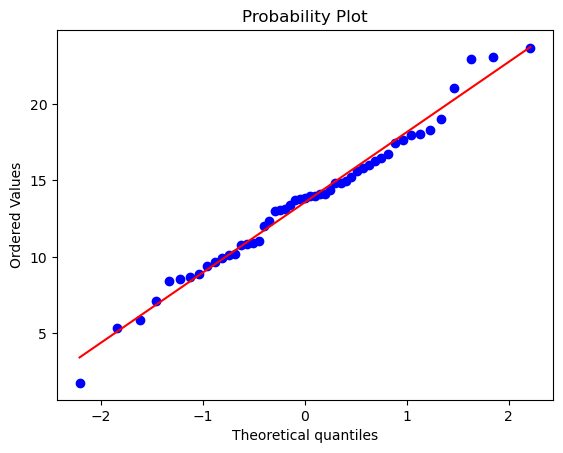

In [394]:
stats.probplot(df["not_distracted"],dist="norm",plot=plt)
plt.show()

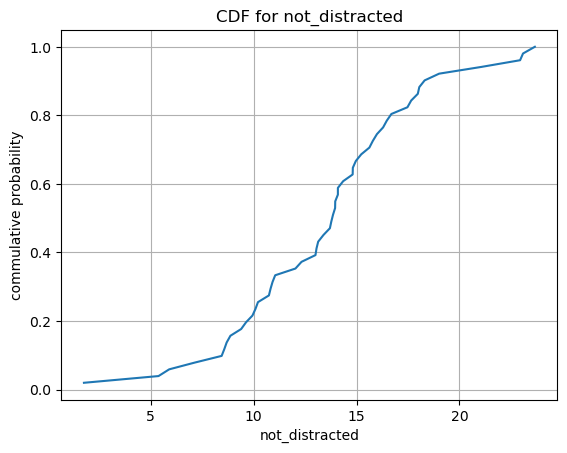

In [395]:
sorted_data=np.sort(df["not_distracted"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for not_distracted")
plt.xlabel("not_distracted")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

<Axes: >

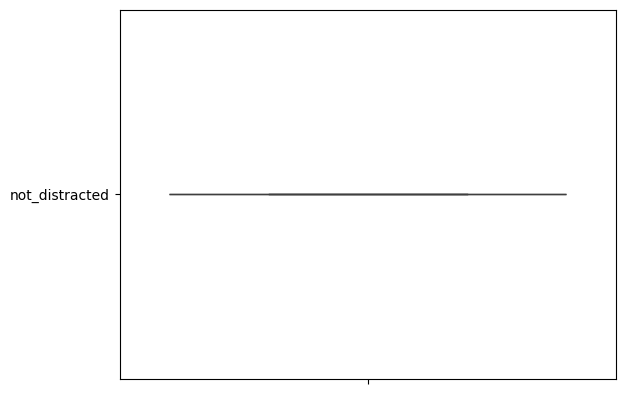

In [396]:
sns.boxplot("not_distracted")

In [397]:
from scipy.stats import kstest
z_score = (df["not_distracted"] - df["not_distracted"].mean()) / df["not_distracted"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
alpha = 0.05
print(pvalue)
if pvalue < alpha:
    print("Reject H0 ")
else:
    print("Fail to reject H0")

0.8975118309777869
Fail to reject H0


In [398]:
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\1806622040.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["no_previous"])


<Axes: xlabel='no_previous', ylabel='Density'>

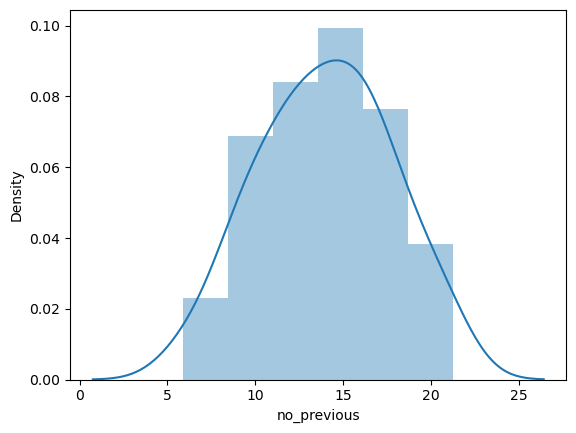

In [399]:
sns.distplot(df["no_previous"])

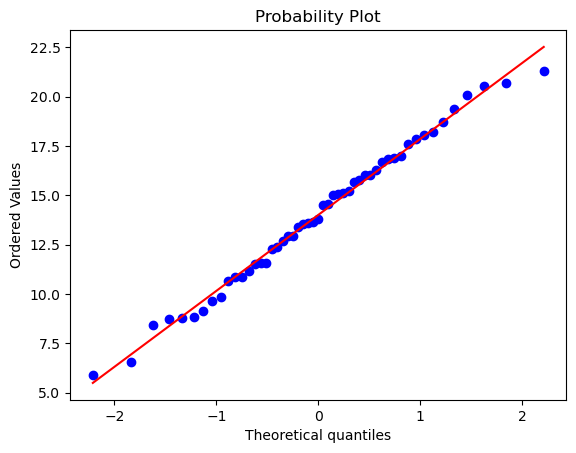

In [400]:
stats.probplot(df["no_previous"],dist="norm",plot=plt)
plt.show()

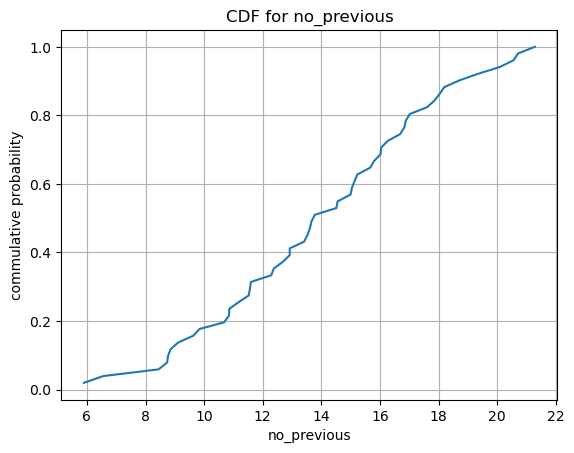

In [401]:
sorted_data=np.sort(df["no_previous"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for no_previous")
plt.xlabel("no_previous")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

In [402]:
# 12 no previous car crashes is 12%

<Axes: ylabel='no_previous'>

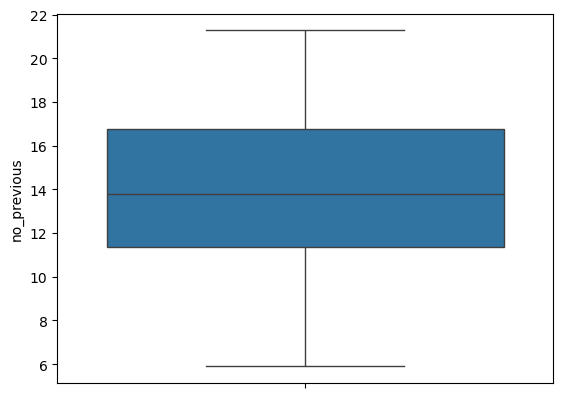

In [403]:
sns.boxplot(df["no_previous"])

# no outlier detected and 50% of data lies between the 11 to 17

In [404]:
# A-D test 
var=anderson(df["no_previous"],dist="norm")

In [405]:
var

AndersonResult(statistic=0.1545023102402041, critical_values=array([0.539, 0.614, 0.736, 0.859, 1.022]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=14.004882352941177, scale=3.7646718988355885)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [406]:
0.1545023102402041 < 0.736

True

In [407]:
# K-S test
from scipy.stats import kstest
z_score = (df["no_previous"] - df["no_previous"].mean()) / df["no_previous"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
print(pvalue)
alpha = 0.05
if pvalue < alpha:
    print("Reject H0 ")
else:
    print("Fail to reject H0")


0.995998063711375
Fail to reject H0


C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\3028344525.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["ins_premium"])


<Axes: xlabel='ins_premium', ylabel='Density'>

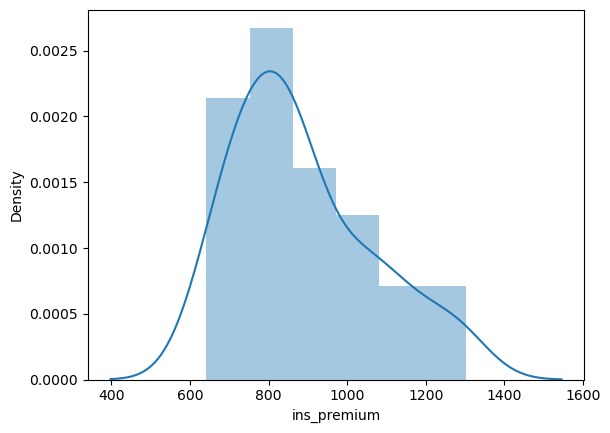

In [408]:
sns.distplot(df["ins_premium"])

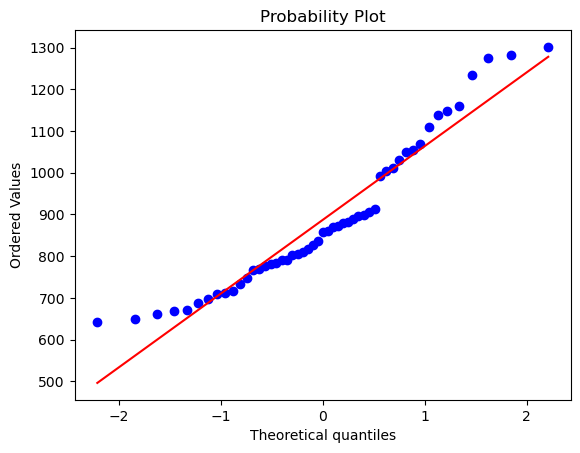

In [409]:
stats.probplot(df["ins_premium"],dist="norm",plot=plt)
plt.show()

In [410]:
stats.kurtosis(df["ins_premium"])

-0.3233852883441073

In [411]:
stats.skew(df["ins_premium"])

0.7557724779257294

# after cheking the skewness we observe that the distribution is right skewed

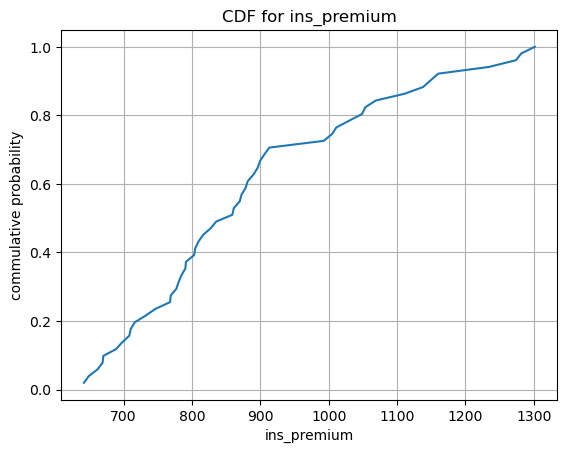

In [412]:
sorted_data=np.sort(df["ins_premium"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for ins_premium")
plt.xlabel("ins_premium")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

less then 80% of premium is 1000

<Axes: ylabel='ins_premium'>

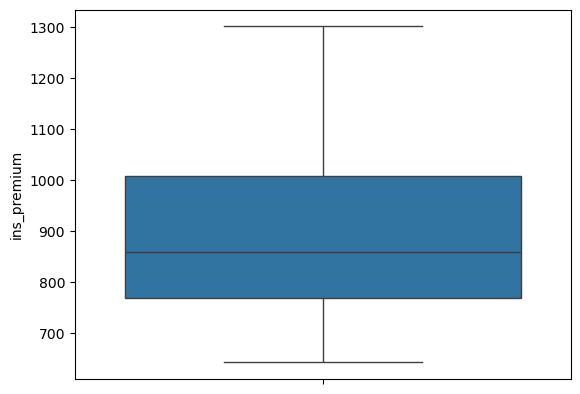

In [413]:
sns.boxplot(df["ins_premium"])

here we sees the data lies between the ins_premium is 780 to 110

In [414]:
# K-S test
from scipy.stats import kstest
z_score = (df["ins_premium"] - df["ins_premium"].mean()) / df["ins_premium"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
print(pvalue)
alpha=0.05
if pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


0.19666357403465085
Fail to reject H0


In [415]:
# A-D test 
var=anderson(df["ins_premium"],dist="norm")

In [416]:
var

AndersonResult(statistic=1.216646138676218, critical_values=array([0.539, 0.614, 0.736, 0.859, 1.022]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=886.9576470588235, scale=178.29628479122306)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

C:\Users\Satna\AppData\Local\Temp\ipykernel_26252\4078262684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["ins_losses"])


<Axes: xlabel='ins_losses', ylabel='Density'>

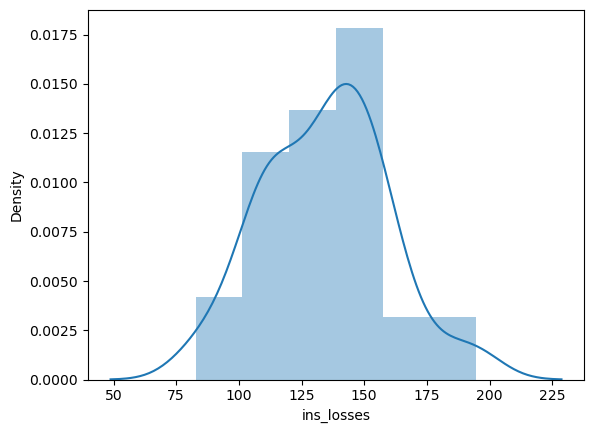

In [417]:
sns.distplot(df["ins_losses"])

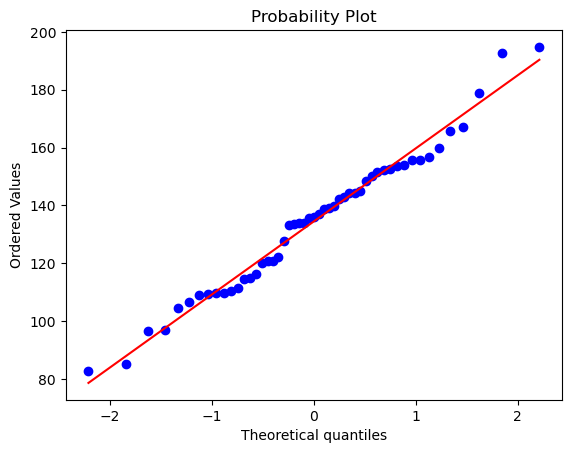

In [418]:
stats.probplot(df["ins_losses"],dist="norm",plot=plt)
plt.show()

In [419]:
stats.kurtosis(df["ins_losses"])

-0.12007194908118057

In [420]:
stats.skew(df["ins_losses"])

0.15923356879999026

# here we sees that the distribution is right skewed

<Axes: ylabel='ins_losses'>

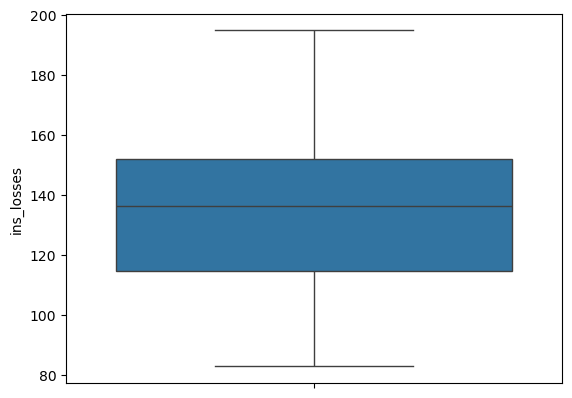

In [421]:
sns.boxplot(df["ins_losses"])

# here we sees that the 50% distribution is lies between 118 to 150

In [422]:
# K-S test
from scipy.stats import kstest
z_score = (df["ins_losses"] - df["ins_losses"].mean()) / df["ins_losses"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
print(pvalue)
alpha=0.05
if pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

0.775346397079358
Fail to reject H0


In [423]:
# A-D test 
var=anderson(df["ins_premium"],dist="norm")

In [424]:
var

AndersonResult(statistic=1.216646138676218, critical_values=array([0.539, 0.614, 0.736, 0.859, 1.022]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=886.9576470588235, scale=178.29628479122306)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [425]:
df["abbrev"].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'], dtype=object)

In [426]:
df.groupby("abbrev")["total"].sum().sort_values(ascending=False).head(5)

abbrev
SC    23.9
ND    23.9
WV    23.8
AR    22.4
KY    21.4
Name: total, dtype: float64

<Axes: xlabel='abbrev,total'>

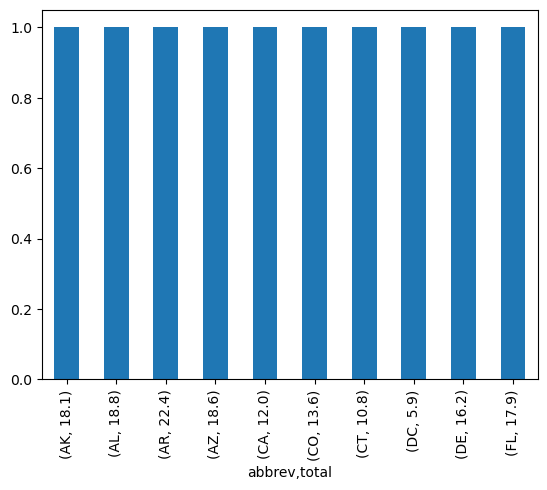

In [427]:
df.groupby("abbrev")["total"].value_counts().head(10).plot(kind="bar")

# the "abbrev" column reprsent the state of U.S .here we sees that top 10 state of U.S with higest car crashes

# Corelation Analysis

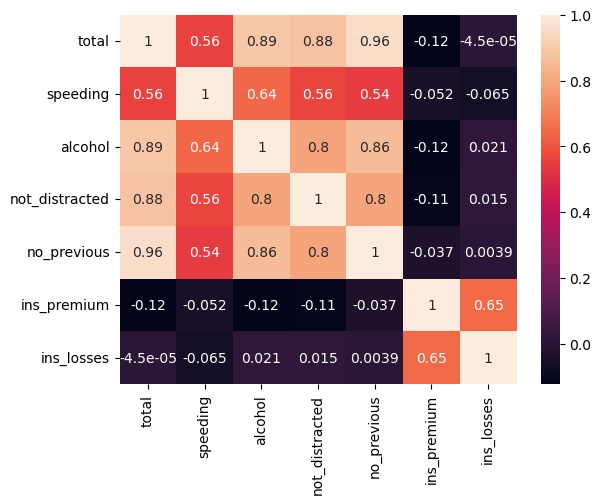

In [430]:
num_df = df.select_dtypes(include=["int64","float64"]) 
sns.heatmap(num_df.corr(method="spearman"),annot=True)
plt.show()


# Conclusion: The analysis identifies speeding and alcohol as key contributors to severe car crashes. EDA plots,
# distribution checking, and hypothesis testing together provide clear, data-driven insights useful for
# road safety